In [2]:
from antspynet.utilities import lung_extraction
from monai.networks.blocks import Warp
import torch
import ants
import os
# from get_lung_volume import get_lung_mask
import numpy as np
import shutil

def plot_ct(img,slices,overlay=None,title=None):
    if overlay!=None:
        img_over = overlay - overlay.min()
    else:
        img_over = None
        
    img2 = img-img.min()
    img2.plot(axis=1,slices=slices,title=title,overlay=img_over,overlay_alpha=0.5)

def compute_volume(img):
    """
    Computes the area (number of pixels) of a binary mask and multiplies the pixels
    with the pixel dimension of the acquired CT image
    Args:
        lung_mask: binary lung mask
        pixdim: list or tuple with two values
    Returns: the lung area in mm^2
    """
    pixdim = img.spacing
    img = img.numpy()
    # img[img >= 0.5] = 1
    # img[img < 0.5] = 0
    lung_pixels = np.sum(img)
    return lung_pixels * pixdim[0] * pixdim[1]* pixdim[2]

def get_lung_mask(img):
    lung_result = lung_extraction(img, modality='ct', verbose=False)
    left_lung = lung_result['probability_images'][1]
    right_lung = lung_result['probability_images'][2]

    left_lung_volume = compute_volume(left_lung)
    right_lung_volume = compute_volume(right_lung)

    return {"left_lung_volume":left_lung_volume,
            "right_lung_volume":right_lung_volume,
            "left_lung":left_lung,
            "right_lung":right_lung}

def resample_dff(ddf_npy_filepath_1,ddf_npy_filepath_2,moving_filepath,fixed_filepath,warp,savepath=None,plot=False):
    moving_img = ants.image_read(moving_filepath)
    fixed_img = ants.image_read(fixed_filepath)



    ddf_1 = []
    for index in range(3):
        ddf_npy_1 = np.load(ddf_npy_filepath_1)[0,index]
        ddf_raw_1 = ants.from_numpy(ddf_npy_1)
        ddf_raw_1 = ants.resample_image(ddf_raw_1,moving_img.shape,True,4)
        ddf_1.append(ddf_raw_1.numpy())
    ddf_1 = torch.tensor(np.array(ddf_1))

    print(f"DDF 1 Shape:{ddf_1.shape}")
    
        
    ddf_2 = ants.image_read(ddf_npy_filepath_2).numpy()

    ddf_2 = ddf_2.transpose(3,0,1,2)
    ddf_2 = torch.tensor(ddf_2)

    print(f"DDF 2 Shape:{ddf_2.shape}")


    img = torch.tensor(moving_img.numpy())
    img = torch.unsqueeze(img, dim=0)
    img = torch.unsqueeze(img, dim=0)
    img = (img+1000.)/3000.
    img[img<0]=0
    img[img>1]=1
    
    ddf_1 = torch.unsqueeze(ddf_1, dim=0)
    ddf_2 = torch.unsqueeze(ddf_2, dim=0)

    output_img_1 = warp(img,ddf_1).numpy()
    output_img_2 = warp(img,ddf_2).numpy()

    print(f"\tIMG shape:{img.shape}")
    print(f"\tDDF 1 shape:{ddf_1.shape}")
    print(f"\tOUT 1 shape:{output_img_1.shape}")
    print(f"\tDDF 2 shape:{ddf_2.shape}")
    print(f"\tOUT 2 shape:{output_img_2.shape}")
    output_img_1 = ants.from_numpy(output_img_1[0,0,:,:,:])
    output_img_1.set_spacing(moving_img.spacing)
    output_img_2 = ants.from_numpy(output_img_2[0,0,:,:,:])
    output_img_2.set_spacing(moving_img.spacing)

    slices = np.linspace((moving_img.shape[1])/4,(moving_img.shape[1])*3/5.,9,dtype=int)

    if plot:
        plot_ct(output_img_1,slices,None,"Fake CT 1")
        plot_ct(output_img_2,slices,None,"Real CT Transform")
        plot_ct(fixed_img,slices,None,"Real CT")
        plot_ct(moving_img,slices,None,"Input CT")

    
    if savepath:
        input_filename = moving_filepath.split("/")[-1]
        real_filename = fixed_filepath.split("/")[-1]
        t_index = ddf_npy_filepath_1.split("/")[-1].split(".")[0].split("_")[2]
        output_filename = ddf_npy_filepath_1.split("/")[-1].split(".")[0].split("_")[1]+"_"+t_index+".nii"
        os.makedirs(os.path.join(savepath,"fake"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"real"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"input"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"real_transform"),exist_ok=True)
        ants.image_write(output_img_1,os.path.join(savepath,"fake",output_filename))
        ants.image_write(fixed_img,os.path.join(savepath,"real",real_filename))
        ants.image_write(output_img_2,os.path.join(savepath,"real_transform",real_filename))
        ants.image_write(moving_img,os.path.join(savepath,"input",input_filename))
   

    return ddf_1,ddf_2,moving_img,fixed_img,output_img_1,output_img_2

monai.networks.blocks.Warp: Using PyTorch native grid_sample.


*Input:/home/zhaosheng/paper4/result0502/199_huzhiwen_ddf1.npy,/home/zhaosheng/4dct_test_nii/huzhiwen/huzhiwen_t0.nii,/home/zhaosheng/4dct_test_nii/huzhiwen/huzhiwen_t1.nii
/home/zhaosheng/4dct_test_nii_transform_SyNAggro/huzhiwen_t1_Warp.nii.gz
DDF 1 Shape:torch.Size([3, 512, 512, 134])
DDF 2 Shape:torch.Size([3, 512, 512, 134])
	IMG shape:torch.Size([1, 1, 512, 512, 134])
	DDF 1 shape:torch.Size([1, 3, 512, 512, 134])
	OUT 1 shape:(1, 1, 512, 512, 134)
	DDF 2 shape:torch.Size([1, 3, 512, 512, 134])
	OUT 2 shape:(1, 1, 512, 512, 134)


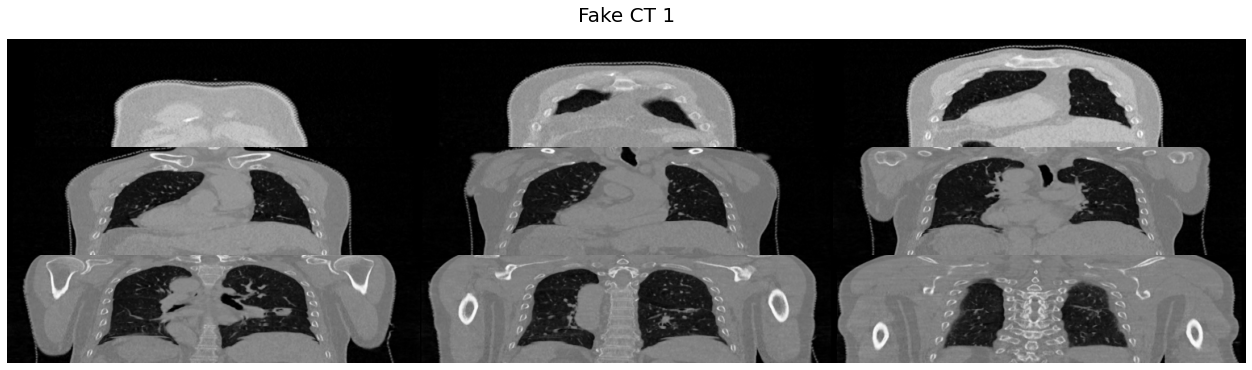

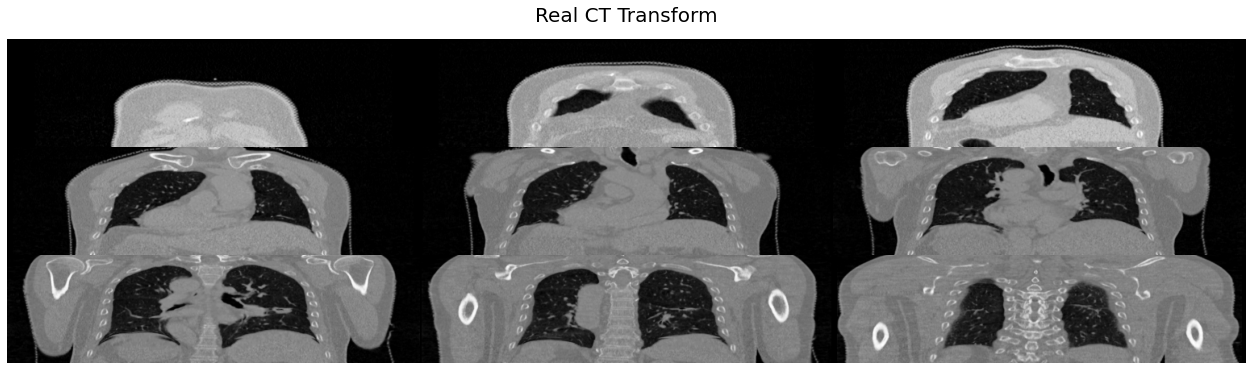

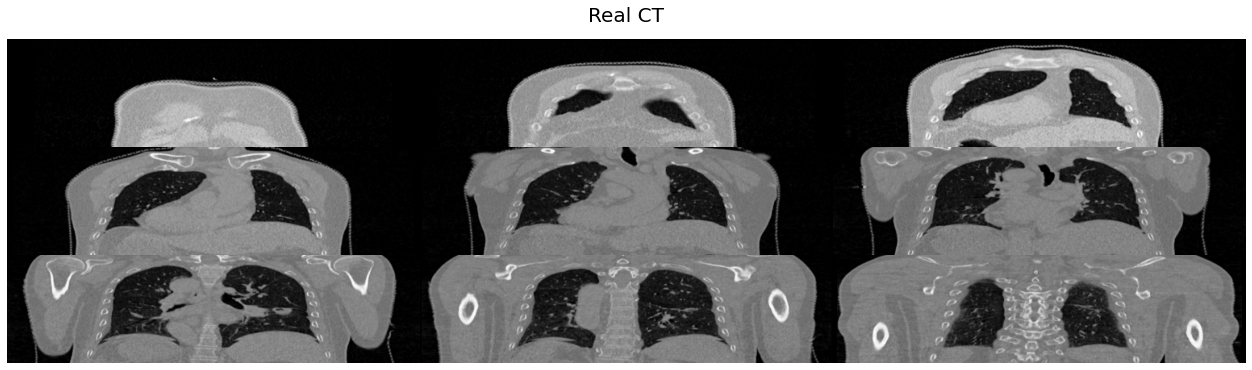

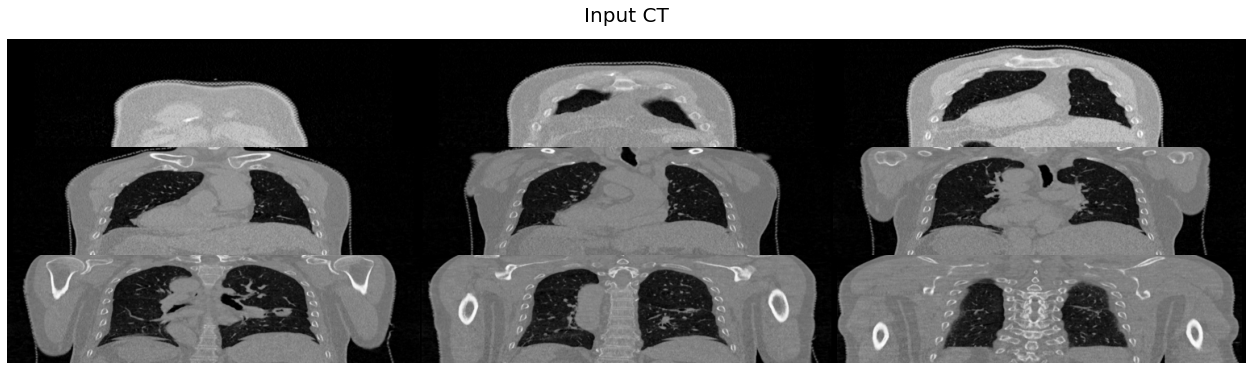

In [5]:
import os
ddf_path = "/home/zhaosheng/paper4/result0502/"


warp = Warp()

def sortddf(item):
    return item.split("/")[-1].split(".")[0].split("_ddf")[-1]

files = sorted([os.path.join(ddf_path,file) for file in os.listdir(ddf_path) if ".npy" in file])
# print(files)
pnames = set([file.split("/")[-1].split("_")[1] for file in files])

for pname in pnames:
    pname = "huzhiwen"
    fake_ddfs_raw = sorted([file for file in files if pname in file],key=sortddf)
    fake_imgs = []
    real_imgs = []
    intput_imgs = []
    real_niis = []
    # real t0~t9
    for index in range(10):
        real_niis.append(f"/home/zhaosheng/4dct_test_nii/{pname}/{pname}_t{index}.nii")
    
    # ddf1~ddf9
    #for index in range(9):
    index = 0
    plot=True

    print(f"*Input:{fake_ddfs_raw[index]},{real_niis[0]},{real_niis[index+1]}")
    # if index==4:
    #     plot=True
    # else:
    #     plot=False
    
    
    transform_nii_file = os.path.join("/home/zhaosheng/4dct_test_nii_transform_SyNAggro/",f"{pname}_t{index+1}_Warp.nii.gz")
    #plot=True
    print(transform_nii_file)
    ddf_1,ddf_2,moving_img,fixed_img,output_img_1,output_img_2 = resample_dff(fake_ddfs_raw[index],transform_nii_file,real_niis[0],real_niis[index+1],warp,savepath="/home/zhaosheng/paper4/results",plot=plot)
    real_lung = get_lung_mask(fixed_img)
    fake_lung = get_lung_mask(output_img_1)
    fake_left_lung_volume =fake_lung["left_lung_volume"]
    fake_right_lung_volume = fake_lung["right_lung_volume"]
    real_left_lung_volume =real_lung["left_lung_volume"]
    real_right_lung_volume = real_lung["right_lung_volume"]
    print(f"\tFake Lung Volume:\t{fake_left_lung_volume}\t{fake_right_lung_volume}")
    print(f"\tReal Lung Volume:\t{real_left_lung_volume}\t{real_right_lung_volume}")
    # break
    
        # fake t1~t9
        # if index==4:
        # fake_imgs.append(output_img)
        # real_imgs.append(fixed_img)
        # intput_imgs.append(moving_img)
        # break
    # print(fake_niis)
    # break


In [ ]:
import os
ddf_path = "/home/zhaosheng/paper4/r"
A2B_epoch = "159"
B2A_epoch = "119"

warp = Warp()
def sortddf(item):
    return item.split("/")[-1].split(".")[0].split("_ddf")[-1]

files = sorted([os.path.join(ddf_path,file) for file in os.listdir(ddf_path) if ".npy" in file])
pnames = set([file.split("/")[-1].split("_")[1] for file in files])

for pname in pnames:
    fake_ddfs_raw = sorted([file for file in files if pname in file],key=sortddf)
    fake_imgs = []
    real_imgs = []
    intput_imgs = []
    real_niis = []
    # real t0~t9
    for index in range(10):
        real_niis.append(f"/zhaosheng_data/4dct_2_test/{pname}/{pname}_t{index}.nii")
    
    # ddf1~ddf9
    for index in range(9):
        print(f"*Input:{fake_ddfs_raw[index]},{real_niis[0]},{real_niis[index+1]}\n")
        if index==4:
            plot=True
        else:
            plot=False
        ddf,moving_img,fixed_img,output_img = resample_dff(fake_ddfs_raw[index],real_niis[0],real_niis[index+1],warp,savepath="/home/zhaosheng/paper4/results_2",plot=plot)
        
        # fake t1~t9
        # if index==4:
        # fake_imgs.append(output_img)
        # real_imgs.append(fixed_img)
        # intput_imgs.append(moving_img)
        # break
    # print(fake_niis)
    # break


In [80]:
npy = np.load("/home/zhaosheng/paper4/result0502/199_pengmeidi_ddf5.npy")[0]
ddf_1 = []
for index in range(3):
    ddf_raw_1 = ants.from_numpy(npy[index])
    ddf_raw_1 = ants.resample_image(ddf_raw_1,moving_img.shape,True,4)
    ddf_1.append(ddf_raw_1.numpy())
ddf_1 = torch.tensor(np.array(ddf_1))

print(ddf_1.shape)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


torch.Size([3, 512, 512, 144])


肿瘤体心 [183.56748306 307.1099531   34.82178218]
torch.Size([1, 1, 512, 512, 144])
torch.Size([1, 1, 512, 512, 144])
torch.Size([1, 1, 512, 512, 144])
torch.Size([1, 3, 512, 512, 144])
形变后肿瘤体心 Real：[  0.           0.         184.25636008 307.83561644  37.33365949]
形变后肿瘤体心 Fake：[  0.           0.         183.30055249 307.02983425  38.3679558 ]
torch.Size([1, 1, 512, 512, 144])
torch.Size([1, 1, 512, 512, 144])
torch.Size([1, 1, 512, 512, 144])


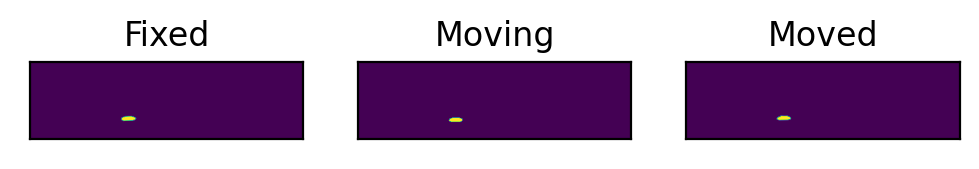

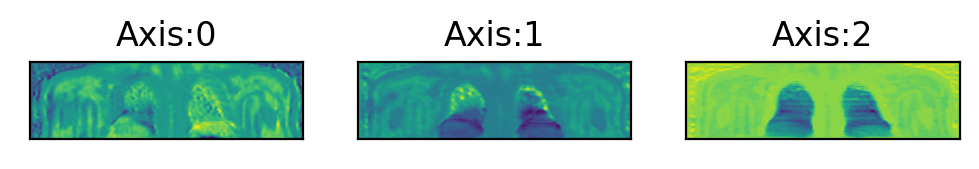

In [141]:
patient_name = "pengmeidi"



from shapely.geometry import Polygon


def getLoc(_npy):
    _npy = np.array(_npy)
    loc = np.mean(np.argwhere(_npy == 1),axis=0)
    return loc

tumor_base = torch.tensor(ants.image_read(f"/dataset1/4dct_test_tumor/{patient_name}.nrrd").numpy())
print(f"肿瘤体心 {getLoc(tumor_base)}")
tumor_base = torch.unsqueeze(tumor_base, dim=0)
tumor_base = torch.unsqueeze(tumor_base, dim=0)
print(tumor_base.shape)

moving = torch.tensor(ants.image_read("/home/zhaosheng/4dct_test_nii/pengmeidi/pengmeidi_t0.nii").numpy())
fixed = torch.tensor(ants.image_read("/home/zhaosheng/4dct_test_nii/pengmeidi/pengmeidi_t5.nii").numpy())
fake_ddf = torch.unsqueeze(ddf_1, dim=0)
real_ddf = torch.tensor(ants.image_read("/home/zhaosheng/4dct_test_nii_transform_SyNAggro/pengmeidi_t5.nii.gz").numpy().transpose(3,0,1,2))
real_ddf = torch.unsqueeze(real_ddf, dim=0)
moving = torch.unsqueeze(moving, dim=0)
moving = torch.unsqueeze(moving, dim=0)
fixed = torch.unsqueeze(fixed, dim=0)
fixed = torch.unsqueeze(fixed, dim=0)
print(moving.shape)
print(fixed.shape)
assert fake_ddf.shape == real_ddf.shape
print(fake_ddf.shape)
moved_real = warp(moving,real_ddf)
moved_fake = warp(moving,fake_ddf)
tumor_after_real = warp(tumor_base,real_ddf)
tumor_after_fake = warp(tumor_base,fake_ddf)
print(f"形变后肿瘤体心 Real：{getLoc(tumor_after_real)}")
print(f"形变后肿瘤体心 Fake：{getLoc(tumor_after_fake)}")


def plot(array,ax,title,tumor=None):
    img = array.numpy()[0,0,:,307,::-1].transpose(1,0)
    
    if tumor != None :
        print(tumor.shape)
        assert tumor.shape == array.shape,"Tumor size error"
        #img[(np.array(tumor)[0,0,:,307,::-1]).transpose(1,0)==1] = 3000
        img = (np.array(tumor)[0,0,:,307,::-1]).transpose(1,0)
    
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    return 0
def plot_ddf(array,ax,title):
    ax.imshow(array)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    return 0

def show_ddf(ddf):
    plt.figure(dpi=200)
    for index in range(3):
        plot_ddf(ddf.numpy()[0,index,:,307,::-1].transpose(1,0),plt.subplot(1,3,index+1),f"Axis:{index}")
    plt.show()
    
import matplotlib.pyplot as plt
# plt.figure(dpi=200)
# plot(fixed,plt.subplot(1,3,1),"Fixed",tumor_base)
# plot(moving,plt.subplot(1,3,2),"Moving",tumor_base)
# plot(moved_real,plt.subplot(1,3,3),"Moved",tumor_after_real)
# plt.show()

# show_ddf(real_ddf)


import matplotlib.pyplot as plt
plt.figure(dpi=200)
plot(fixed,plt.subplot(1,3,1),"Fixed",tumor_after_real)
plot(moving,plt.subplot(1,3,2),"Moving",tumor_base)
plot(moved_fake,plt.subplot(1,3,3),"Moved",tumor_after_fake)
plt.show()

show_ddf(fake_ddf)

In [132]:
patient_name = "pengmeidi"



from shapely.geometry import Polygon


def getLoc(_npy):
    _npy = np.array(_npy)
    loc = np.mean(np.argwhere(_npy == 1),axis=0)
    return loc

tumor_base = torch.tensor(ants.image_read(f"/dataset1/4dct_test_tumor/{patient_name}.nrrd").numpy())
print(f"肿瘤体心 {getLoc(tumor_base)}")
tumor_base = torch.unsqueeze(tumor_base, dim=0)
tumor_base = torch.unsqueeze(tumor_base, dim=0)
print(tumor_base.shape)

肿瘤体心 [183.56748306 307.1099531   34.82178218]
torch.Size([1, 1, 512, 512, 144])


In [133]:
tumor_base

tensor([[[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          ...,

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           

monai.networks.blocks.Warp: Using PyTorch native grid_sample.


Loading tumor, Shape: {self.tumor_base.shape}
肿瘤体心 [  0.           0.         183.56748306 307.1099531   34.82178218]


In [2]:
from get_loc_results import Patient
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
plt.style.use('ggplot')

results = {}
for pname in tqdm(sorted([_file.split(".")[0] for _file in  os.listdir("/home/zhaosheng/4dct_test_nii")])[1:]):
    results[pname]={}
    test = Patient(pname,"/home/zhaosheng/paper4/results0505/")
    real_loc,fake_loc = test._getImage()
#     plt.figure(dpi=200)
#     plt.title(f"GTV location")
#     results[pname]["real_loc"] = real_loc
#     results[pname]["fake_loc"] = fake_loc
#     fake_loc = fake_loc - fake_loc[0]
#     real_loc = real_loc - real_loc[0]
#     # plt.plot(np.array(fake_loc)[:,-3],linewidth=3,label="X axis")
#     # plt.plot(np.array(real_loc)[:,-3],linewidth=3,label="X axis")

#     # plt.plot(np.array(fake_loc)[:,-2],linewidth=3,label="Y axis")
#     # plt.plot(np.array(real_loc)[:,-2],linewidth=3,label="Y axis")

#     plt.plot(np.array(fake_loc)[:,-1],linewidth=3,label="Z axis")
#     plt.plot(np.array(real_loc)[:,-1],linewidth=3,label="Z axis")

#     plt.legend()
#     plt.legend()
#     plt.show()
    

  0%|          | 0/17 [00:00<?, ?it/s]monai.networks.blocks.Warp: Using PyTorch native grid_sample.

  0%|          | 0/9 [00:00<?, ?it/s]

Get base Image: Success!



  0%|          | 0/9 [00:00<?, ?it/s]

Get base Image: Success!



  0%|          | 0/9 [00:00<?, ?it/s]

...


  0%|          | 0/9 [00:00<?, ?it/s]

Get base Image: Success!



  0%|          | 0/9 [00:00<?, ?it/s]

Get base Image: Success!



100%|██████████| 17/17 [1:06:28<00:00, 234.61s/it]


In [3]:
sorted([_file.split(".")[0] for _file in  os.listdir("/dataset1/4dct_test_tumor") if "nrrd" in _file])

['caowujun',
 'chenguangdeng',
 'chenjinsheng',
 'chenkemo',
 'chenshufang',
 'guixiufang',
 'hanjiangying',
 'hexiaochun',
 'huyannian',
 'huzhiwen',
 'jimeihong',
 'jinyurong',
 'liuwansheng',
 'liuyoukai',
 'liyifeng',
 'lubaimei',
 'lvqingcheng',
 'pengmeidi']